# 04 - Entrenar y evaluar XGBoost afinado

Permite elegir hiperpar?metros: del profe (`lpmc_xgb_best_params.json`) o los tuyos (`lpmc_xgb_custom_params.json`). Usa `RANDOM_STATE=481516` si el JSON lo incluye.


In [31]:
from pathlib import Path
import json
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data' / 'preprocessed'
ARTIFACTS = ROOT / 'artifacts'
MODELS = ROOT / 'models'
MODELS.mkdir(exist_ok=True)

DEFAULT_SCALED_FEATURES = [
    'day_of_week', 'start_time_linear', 'age', 'car_ownership',
    'distance', 'dur_walking', 'dur_cycling', 'dur_pt_access', 'dur_pt_rail',
    'dur_pt_bus', 'dur_pt_int_waiting', 'dur_pt_int_walking', 'pt_n_interchanges',
    'dur_driving', 'cost_transit', 'cost_driving_total',
]


In [32]:
PARAM_SOURCE = 'custom'  # 'profe' o 'custom'

PROF_PATH = ARTIFACTS / 'lpmc_xgb_best_params.json'
CUSTOM_PATH = ARTIFACTS / 'lpmc_xgb_custom_params.json'

def load_params(source: str):
    if source == 'custom' and CUSTOM_PATH.exists():
        bundle = json.loads(CUSTOM_PATH.read_text())
        print('Usando hiperpar?metros CUSTOM de', CUSTOM_PATH)
        return bundle
    bundle = json.loads(PROF_PATH.read_text())
    if source == 'custom':
        print('No se encontr? custom; se usan los del profe en su lugar.')
    else:
        print('Usando hiperpar?metros del profe de', PROF_PATH)
    return bundle

bundle = load_params(PARAM_SOURCE)
model_params = bundle['params']
scaled_features = bundle.get('scaled_features', DEFAULT_SCALED_FEATURES)
print('Parametros activos:')
for k, v in model_params.items():
    print(f"  {k}: {v}")


Usando hiperpar?metros CUSTOM de f:\TFM\lpmc\artifacts\lpmc_xgb_custom_params.json
Parametros activos:
  colsample_bytree: 0.9911780478619544
  gamma: 2.499996019648383
  learning_rate: 0.09258949217113338
  max_depth: 6
  min_child_weight: 17
  n_estimators: 900
  reg_alpha: 0.6836695859198154
  reg_lambda: 0.053597416554023405
  subsample: 0.6206611465973016
  objective: multi:softprob
  eval_metric: mlogloss
  num_class: 4
  n_jobs: -1
  random_state: 481516


In [33]:
target_col = 'travel_mode'
train = pd.read_csv(DATA_DIR / 'LPMC_train.csv')
test = pd.read_csv(DATA_DIR / 'LPMC_test.csv')

X_train = train.drop(columns=[target_col])
y_train = train[target_col].astype(int)
X_test = test.drop(columns=[target_col])
y_test = test[target_col].astype(int)

missing_in_test = set(X_train.columns) - set(X_test.columns)
for c in missing_in_test:
    X_test[c] = 0
missing_in_train = set(X_test.columns) - set(X_train.columns)
for c in missing_in_train:
    X_train[c] = 0
X_test = X_test[X_train.columns]


In [34]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scaled_features] = scaler.fit_transform(X_train[scaled_features].astype(float))
X_test_scaled[scaled_features] = scaler.transform(X_test[scaled_features].astype(float))

fast_override = os.environ.get('FAST_N_ESTIMATORS')
if fast_override:
    model_params = dict(model_params)
    model_params['n_estimators'] = int(fast_override)
    print('FAST_N_ESTIMATORS activo -> n_estimators', model_params['n_estimators'])

clf = XGBClassifier(**model_params)
print('Entrenando XGBClassifier...')
clf.fit(X_train_scaled, y_train)


Entrenando XGBClassifier...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9911780478619544, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None,
              gamma=2.499996019648383, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.09258949217113338,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=17, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=900, n_jobs=-1, num_class=4,
              num_parallel_tree=None, ...)

In [35]:
proba_train = clf.predict_proba(X_train_scaled)
proba_test = clf.predict_proba(X_test_scaled)
y_pred_train = clf.predict(X_train_scaled)
y_pred_test = clf.predict(X_test_scaled)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

def gmpca_from_proba(proba, y_true):
    proba = np.asarray(proba)
    y_true = np.asarray(y_true)
    proba = np.clip(proba, 1e-12, 1.0)
    log_like = np.log(proba[np.arange(len(y_true)), y_true]).sum()
    return float(np.exp(log_like / len(y_true)))

gmpca_train = gmpca_from_proba(proba_train, y_train)
gmpca_test = gmpca_from_proba(proba_test, y_test)

print(f'Accuracy train: {acc_train:.4f} ({acc_train*100:.2f}%)')
print(f'Accuracy test : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'GMPCA train   : {gmpca_train:.4f} ({gmpca_train*100:.2f}%)')
print(f'GMPCA test    : {gmpca_test:.4f} ({gmpca_test*100:.2f}%)')


Accuracy train: 0.8009 (80.09%)
Accuracy test : 0.7425 (74.25%)
GMPCA train   : 0.5971 (59.71%)
GMPCA test    : 0.5101 (51.01%)


In [36]:
print('Classification report (test):')
print(classification_report(y_test, y_pred_test))


Classification report (test):
              precision    recall  f1-score   support

           0       0.66      0.68      0.67      4684
           1       0.19      0.01      0.02       861
           2       0.76      0.76      0.76      9501
           3       0.76      0.81      0.79     11274

    accuracy                           0.74     26320
   macro avg       0.59      0.56      0.56     26320
weighted avg       0.73      0.74      0.73     26320



WindowsPath('f:/TFM/lpmc/artifacts/xgb_confusion_matrix_tuned.png')

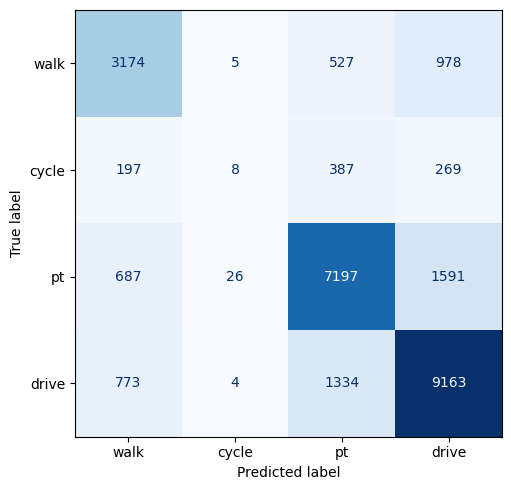

In [37]:
cm = confusion_matrix(y_test, y_pred_test, labels=[0,1,2,3])
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['walk','cycle','pt','drive'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.tight_layout()
cm_path = ARTIFACTS / 'xgb_confusion_matrix_tuned.png'
plt.savefig(cm_path, dpi=150)
cm_path


In [38]:
model_path = MODELS / 'xgb_lpmc_tuned.joblib'
scaler_path = MODELS / 'xgb_lpmc_scaler.joblib'
joblib.dump({'model': clf, 'feature_names': list(X_train_scaled.columns)}, model_path)
joblib.dump({'scaler': scaler, 'scaled_features': scaled_features}, scaler_path)

metrics_path = ARTIFACTS / 'xgb_lpmc_metrics.json'
metrics_payload = {
    'train': {'accuracy': acc_train, 'gmpca': gmpca_train},
    'test': {'accuracy': acc_test, 'gmpca': gmpca_test},
    'model_params': model_params,
    'param_source': PARAM_SOURCE,
}
metrics_path.write_text(json.dumps(metrics_payload, indent=2))

print('Modelo guardado en', model_path)
print('Scaler guardado en', scaler_path)
print('Metricas guardadas en', metrics_path)


Modelo guardado en f:\TFM\lpmc\models\xgb_lpmc_tuned.joblib
Scaler guardado en f:\TFM\lpmc\models\xgb_lpmc_scaler.joblib
Metricas guardadas en f:\TFM\lpmc\artifacts\xgb_lpmc_metrics.json
